# Paper Plots/Animations

Plots for the upcoming paper; most of which are found in other notebooks in this repository, but just putting them all here to have a record.

In [14]:
import matplotlib.pyplot as plt
import xarray as xr
import seaborn as sns
from pathlib import Path
import os
import matplotlib.path as mpath
import matplotlib.colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
import pandas as pd
from matplotlib.cm import prism
import numpy as np

curwd = os.getcwd()
os.chdir(str(Path(os.getcwd()).parents[0]) + '/scripts/')
import utils
os.chdir(str(Path(os.getcwd())) + '/clustering/')
import st_dbscan as st
os.chdir(curwd)



## Main Paper

### Tracker

Showing how the two-stage clustering works.

In [15]:
catalogs = utils.load_catalogs(years=[1980])

In [16]:
subcatalog = catalogs.isel(time=slice(120, 140))

# hyperparameters  
synoptic_scale = 10**3
km_per_radian = 6.371*(10**3) # arclength (km) on earth subtended by 1 radian

eps_space = synoptic_scale/(2*km_per_radian) # converted to radians for Haversine metric
eps_space_1 = eps_space
eps_space_2 = eps_space
eps_time = 18/24
minpts_1 = 5
minpts_2 = 5
n_rep_pts = 10

# instantiating the clustering object
cluster_obj = st.ST_DBSCAN(eps_space_1, eps_space_2, eps_time, minpts_1, minpts_2, n_rep_pts)
# doing the spatiotemporal clustering
df = cluster_obj.fit(subcatalog)

Beginning spatial clustering step.


100%|██████████| 20/20 [00:03<00:00,  5.52it/s]
/global/u1/j/jbbutler/extreme_antarctic_ARs/scripts/clustering/st_dbscan.py:82: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ar_pt_df['cluster'] = np.full(cluster_infos_df.shape[0], np.nan)


Beginning spatiotemporal clustering step.


In [25]:
time = df.iloc[9].time
time

Timestamp('1980-02-08 06:00:00')

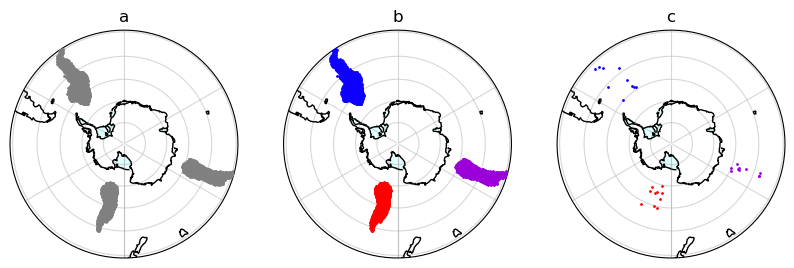

In [24]:
# instantiate the animation
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10,5), subplot_kw=dict(projection=ccrs.Stereographic(central_longitude=0., central_latitude=-90.)))

unique_clusters = df['cluster'].unique()
color_mapping = {unique_clusters[j]:prism(j/12) for j in range(len(unique_clusters)) }

if (time == df.time).any():
    dat = df[df['time'] == time]
    n_clusts = dat.shape[0]

    for i in range(n_clusts):
        cluster = dat['cluster'].iloc[i]
        ax[0].scatter(dat['lons'].iloc[i], dat['lats'].iloc[i], transform=ccrs.PlateCarree(), s=1, color='gray', zorder=30)
        ax[1].scatter(dat['lons'].iloc[i], dat['lats'].iloc[i], transform=ccrs.PlateCarree(), s=1, color=color_mapping[cluster], label=str(cluster), zorder=30)
        ax[2].scatter(dat['rep_lons'].iloc[i], dat['rep_lats'].iloc[i], transform=ccrs.PlateCarree(), s=1, color=color_mapping[cluster], label=str(cluster), zorder=30)

for i in range(len(ax)):

    ax[i].set_extent([-180,180,-90,-39], ccrs.PlateCarree())
    ice_shelf_poly = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_polys', '50m',edgecolor='none',facecolor='lightcyan') # 10m, 50m, 110m
    ax[i].add_feature(ice_shelf_poly,linewidth=3)
    ice_shelf_line = cfeature.NaturalEarthFeature('physical', 'antarctic_ice_shelves_lines', '50m',edgecolor='black',facecolor='none') # 10m, 50m, 110m
    ax[i].add_feature(ice_shelf_line,linewidth=1,zorder=13)
    ax[i].coastlines(resolution='110m',linewidth=1,zorder=32)

    
    # Map extent 
    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax[i].set_boundary(circle, transform=ax[i].transAxes)
    ax[i].gridlines(alpha=0.5, zorder=33)
    
    time_ts = pd.Timestamp(time)
    
ax[0].set_title('a')
ax[1].set_title('b')
ax[2].set_title('c')

plt.savefig('../plots/paper_plots/spatial_clustering.png')

In [19]:
unpacked_df = cluster_obj.unpack_df(df)

In [20]:
unpacked_df = unpacked_df[unpacked_df.time.dt.day == 8]

0       7
1       7
2       7
3       7
4       7
       ..
732    10
733    10
734    10
735    10
736    10
Name: time, Length: 737, dtype: int32

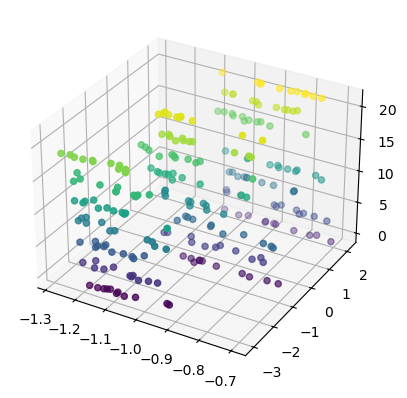

In [21]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(unpacked_df.lat, unpacked_df.lon, unpacked_df.time.dt.hour, c=unpacked_df.space_cluster)


## Supplementary Material

In [ ]:
global/homes/j/jbbutler/extreme_antarctic_ARs/scripts/clustering/__init__.py